Loading batteries...
Batt1   : 43,171 rows | SOC [0.0–100.0%] | 2023-04-01 → 2023-04-30
Batt7   : 43,171 rows | SOC [0.0–87.1%] | 2023-04-01 → 2023-04-30
Batt8   : 43,171 rows | SOC [0.0–87.1%] | 2023-04-01 → 2023-04-30
Batt10  : 43,171 rows | SOC [19.9–71.1%] | 2023-04-01 → 2023-04-30


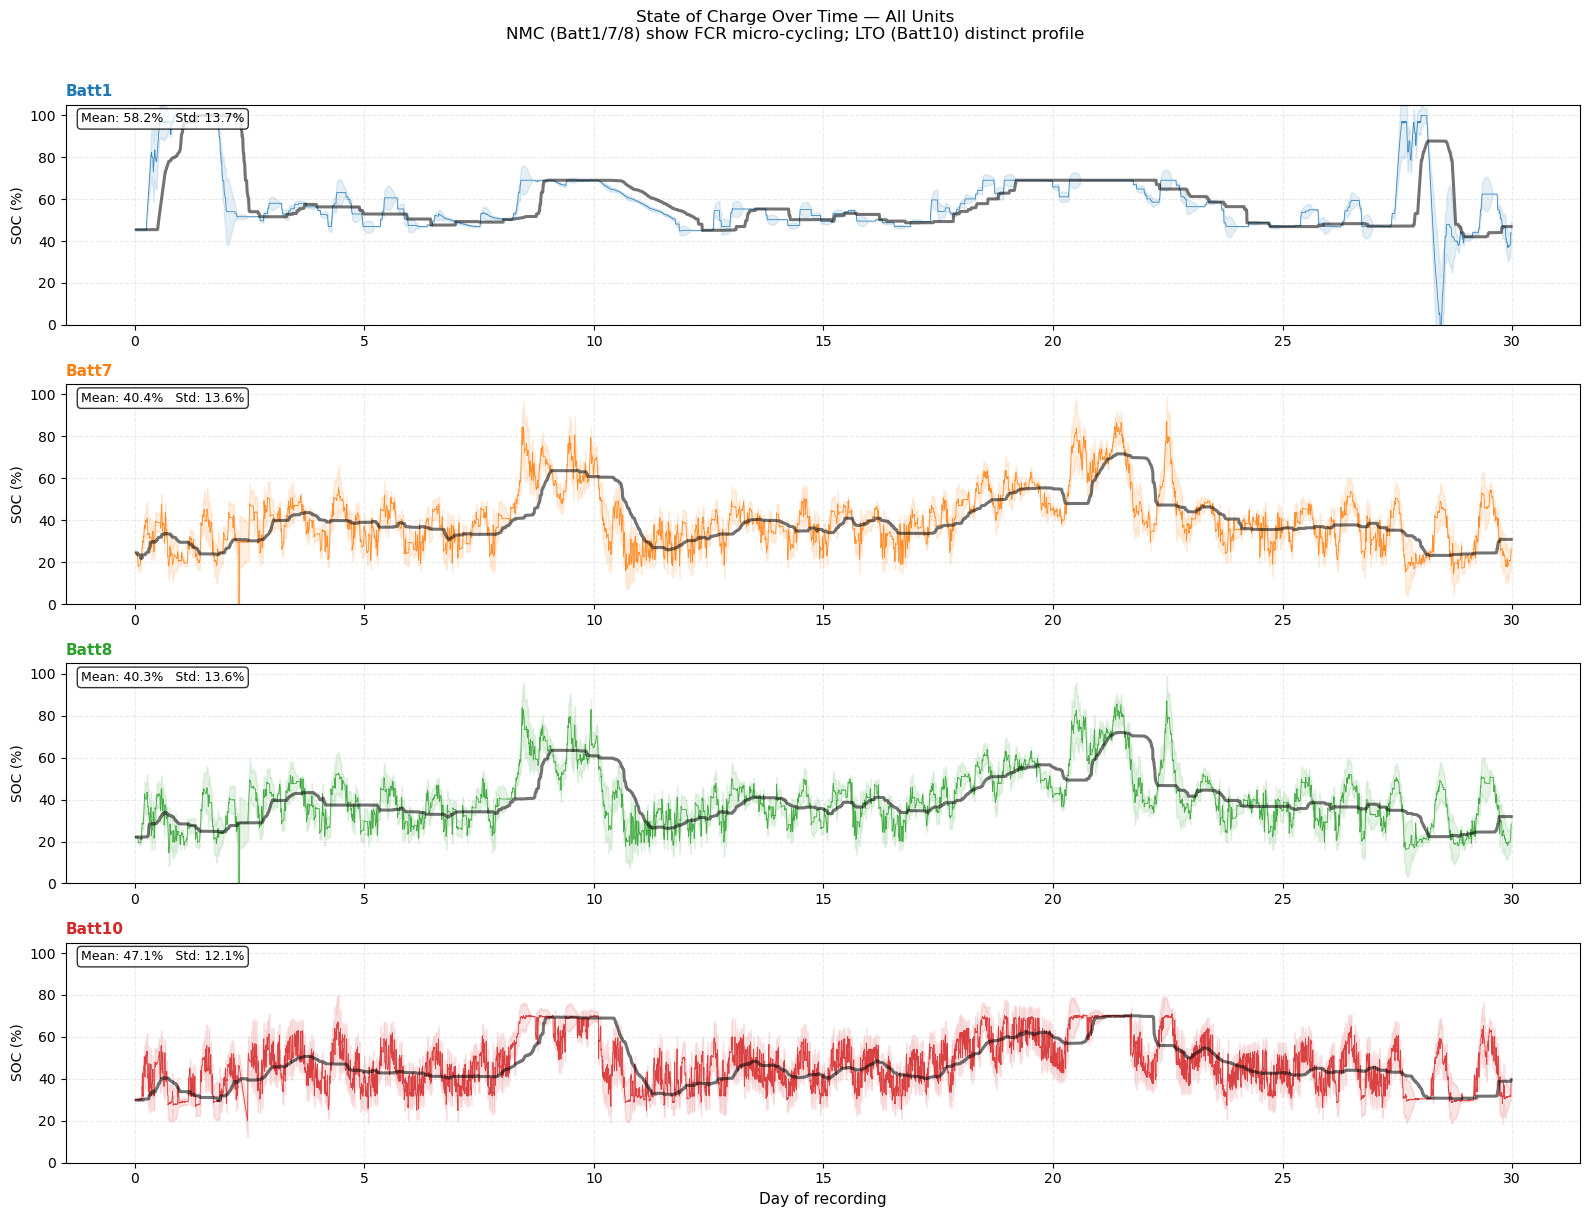

Saved → thesis_soc_over_time.png


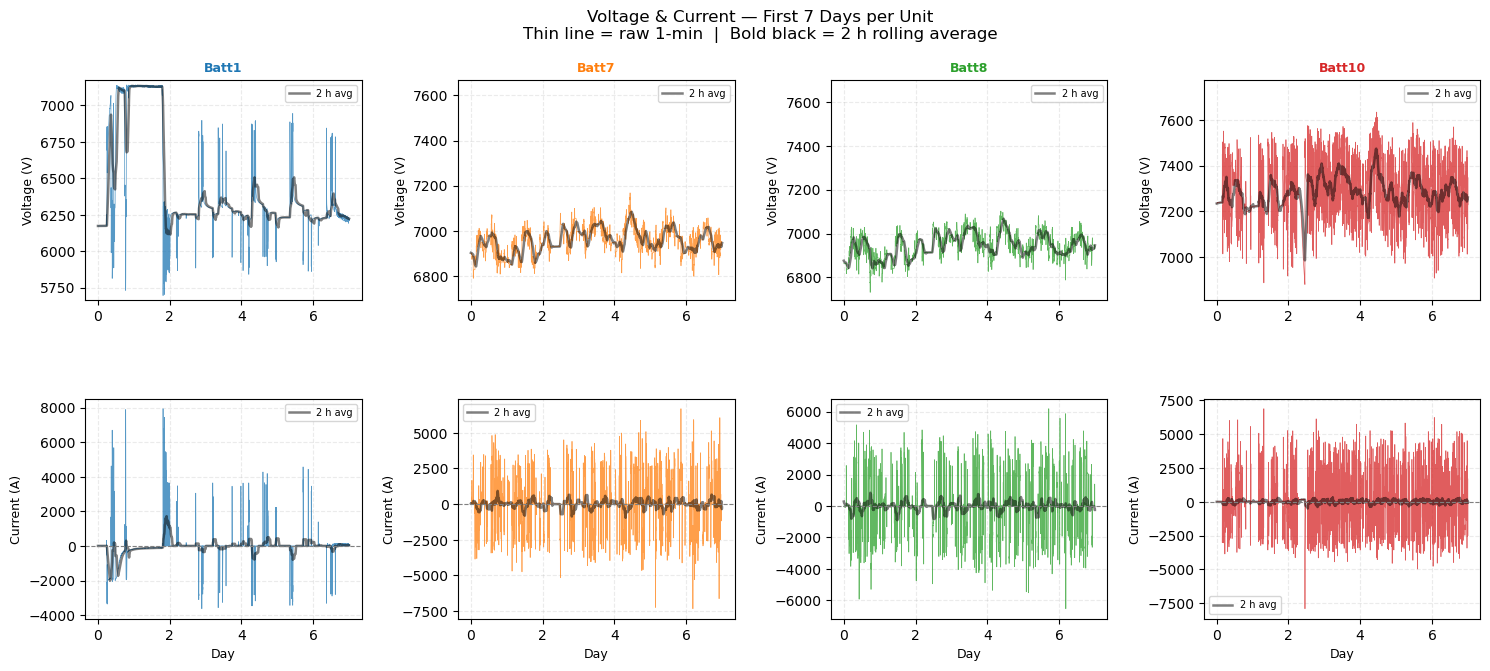

Saved → thesis_VI_timeseries.png


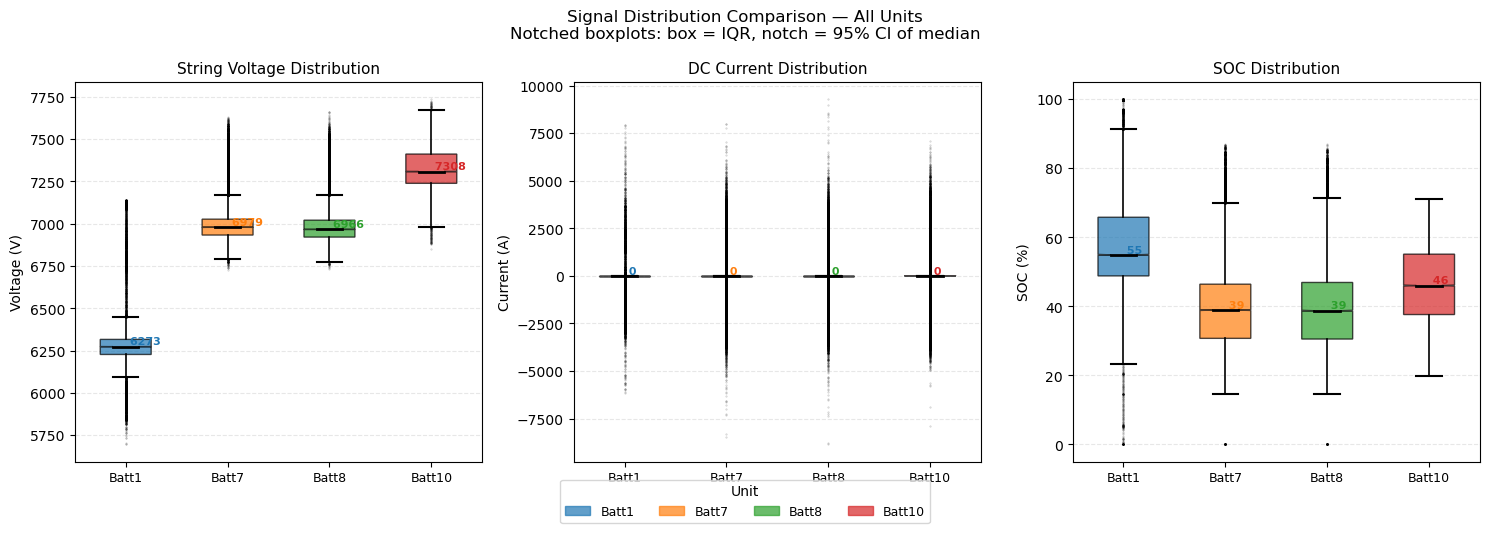

Saved → thesis_VI_distributions.png

All plots generated successfully.


In [1]:
"""
Exploratory plots – all 4 units (Batt1, Batt7, Batt8, Batt10)
- SOC over time 
- Voltage & Current timeseries 
- Distribution boxplots 
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────────────────────
DATA_DIR = 'data/M5BAT'
FIG_DIR  = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

UNITS = {
    'Batt1': 'Batt1.csv',
    'Batt7': 'Batt7.csv',
    'Batt8': 'Batt8.csv',
    'Batt10': 'Batt10.csv',
}
UNIT_COLORS = {
    'Batt1': '#1f77b4',
    'Batt7': '#ff7f0e',
    'Batt8': '#2ca02c',
    'Batt10': '#d62728',
}
UNIT_SHORT = {
    'Batt1': 'Batt1',
    'Batt7': 'Batt7',
    'Batt8': 'Batt8',
    'Batt10': 'Batt10',
}

RAW_COLS  = ['U_DC_Batt', 'I_DC_Batt']
RESAMPLE  = '1min'
AVG_WIN   = 120   # 2-hour window

# ── Data loading ─────────────────────────────────────────────────────────────
def load_and_process(filepath):
    bname = os.path.basename(filepath).replace('.csv', '')
    df = pd.read_csv(
        filepath, sep=';',
        parse_dates=['DateAndTime'],
        infer_datetime_format=True,
        low_memory=False
    ).set_index('DateAndTime').sort_index()

    df['SOC'] = df['SOC'] / 10.0
    if 'interpolated' in df.columns:
        df = df[df['interpolated'] == 0]

    df = df[RAW_COLS + ['SOC']]
    df_min = df.resample(RESAMPLE).agg(
        {**{c: 'mean' for c in RAW_COLS}, 'SOC': 'last'}
    ).dropna()

    df_min['V_avg_2h'] = df_min['U_DC_Batt'].rolling(AVG_WIN, min_periods=30).mean()
    df_min['I_avg_2h'] = df_min['I_DC_Batt'].rolling(AVG_WIN, min_periods=30).mean()
    df_min = df_min.dropna()

    print(f'{bname:8s}: {len(df_min):,} rows | '
          f'SOC [{df_min.SOC.min():.1f}–{df_min.SOC.max():.1f}%] | '
          f'{df_min.index[0].date()} → {df_min.index[-1].date()}')
    return df_min

print('Loading batteries...')
viz_units = {}
for unit_label, fname in UNITS.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing {path}')
    viz_units[unit_label] = load_and_process(path)

n_units = len(viz_units)   # 4

# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 1 – SOC over time 
# ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_units, 1, figsize=(16, 12), sharex=False)

for ax, (unit_label, df) in zip(axes, viz_units.items()):
    color = UNIT_COLORS[unit_label]
    t_days = np.arange(len(df)) / (60 * 24)

    ax.plot(t_days, df['SOC'].values, lw=0.6, color=color, alpha=0.85)

    # Rolling median without label (no legend)
    daily_med = df['SOC'].rolling(window=60*24, min_periods=60).median()
    ax.plot(t_days, daily_med.values, lw=2.2, color='black', alpha=0.55)

    daily_std = df['SOC'].rolling(window=60*6, min_periods=30).std()
    ax.fill_between(t_days,
                     df['SOC'].values - daily_std.values,
                     df['SOC'].values + daily_std.values,
                     alpha=0.12, color=color)

    # Stats – Range removed
    soc_mean = df['SOC'].mean()
    soc_std  = df['SOC'].std()
    ax.text(0.01, 0.92,
            f'Mean: {soc_mean:.1f}%   Std: {soc_std:.1f}%',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_ylabel('SOC (%)', fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_title(UNIT_SHORT[unit_label], fontsize=11,
                 fontweight='bold', color=color, loc='left')
    ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
    ax.grid(axis='both', alpha=0.25, linestyle='--')
    # No legend call

axes[-1].set_xlabel('Day of recording', fontsize=11)

plt.suptitle(
    'State of Charge Over Time — All Units\n'
    'NMC (Batt1/7/8) show FCR micro-cycling; LTO (Batt10) distinct profile',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'thesis_soc_over_time.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved → thesis_soc_over_time.png')

# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 2 – Voltage & Current timeseries 
# ────────────────────────────────────────────────────────────────────────────
DAYS_SHOW = 7

fig, axes = plt.subplots(2, n_units, figsize=(18, 7),
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.35})

for col, (unit_label, df) in enumerate(viz_units.items()):
    color = UNIT_COLORS[unit_label]
    n_pts = min(DAYS_SHOW * 24 * 60, len(df))
    t     = np.arange(n_pts) / (60 * 24)

    # Voltage
    ax = axes[0, col]
    ax.plot(t, df['U_DC_Batt'].values[:n_pts], lw=0.5, color=color, alpha=0.75)
    ax.plot(t, df['V_avg_2h'].values[:n_pts], lw=1.8, color='black',
            alpha=0.5, label='2 h avg')
    ax.set_title(UNIT_SHORT[unit_label], fontsize=9,
                 fontweight='bold', color=color)
    ax.set_ylabel('Voltage (V)', fontsize=9)
    ax.set_ylim(df['U_DC_Batt'].min() * 0.995,
                df['U_DC_Batt'].max() * 1.005)
    ax.grid(alpha=0.25, ls='--')
    ax.legend(fontsize=7)

    # Current
    ax = axes[1, col]
    ax.plot(t, df['I_DC_Batt'].values[:n_pts], lw=0.5, color=color, alpha=0.75)
    ax.plot(t, df['I_avg_2h'].values[:n_pts], lw=1.8, color='black',
            alpha=0.5, label='2 h avg')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_ylabel('Current (A)', fontsize=9)
    ax.set_xlabel('Day', fontsize=9)
    ax.grid(alpha=0.25, ls='--')
    ax.legend(fontsize=7)

fig.suptitle(
    f'Voltage & Current — First {DAYS_SHOW} Days per Unit\n'
    'Thin line = raw 1-min  |  Bold black = 2 h rolling average',
    fontsize=12
)
plt.savefig(os.path.join(FIG_DIR, 'thesis_VI_timeseries.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved → thesis_VI_timeseries.png')

# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 3 – Distribution boxplots
# ────────────────────────────────────────────────────────────────────────────
unit_names_short = ['Batt1', 'Batt7', 'Batt8', 'Batt10'] 
colors_list      = list(UNIT_COLORS.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat, ylabel, title in zip(
        axes,
        ['U_DC_Batt', 'I_DC_Batt', 'SOC'],
        ['Voltage (V)', 'Current (A)', 'SOC (%)'],
        ['String Voltage Distribution',
         'DC Current Distribution',
         'SOC Distribution']):

    data = [df[feat].values for df in viz_units.values()]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        notch=True,
        vert=True,
        widths=0.5,
        medianprops=dict(color='black', lw=2),
        whiskerprops=dict(lw=1.2),
        capprops=dict(lw=1.5),
        flierprops=dict(marker='.', markersize=1, alpha=0.2),
    )
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, n_units + 1))
    ax.set_xticklabels(unit_names_short, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3, ls='--')

    # Annotate median
    for i, (med, color) in enumerate(zip(
            [np.median(d) for d in data], colors_list)):
        ax.text(i+1, med, f' {med:.0f}', va='bottom',
                fontsize=8, color=color, fontweight='bold')

legend_patches = [
    mpatches.Patch(color=c, alpha=0.7, label=n)
    for c, n in zip(colors_list, unit_names_short)
]
fig.legend(handles=legend_patches, loc='lower center', ncol=n_units,
           fontsize=9, title='Unit', bbox_to_anchor=(0.5, -0.06))

plt.suptitle(
    'Signal Distribution Comparison — All Units\n'
    'Notched boxplots: box = IQR, notch = 95% CI of median',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'thesis_VI_distributions.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved → thesis_VI_distributions.png')

print('\nAll plots generated successfully.')

In [2]:
print("\nSummary statistics for each unit:\n")
print(f"{'Unit':<8} {'SOC min':>8} {'SOC max':>8} {'SOC mean':>8} {'SOC std':>8} {'V median':>8} {'I median':>8}")
print("-" * 70)
for unit, df in viz_units.items():
    soc = df['SOC']
    v   = df['U_DC_Batt']
    i   = df['I_DC_Batt']
    print(f"{unit:<8} {soc.min():8.1f} {soc.max():8.1f} {soc.mean():8.1f} {soc.std():8.1f} {v.median():8.0f} {i.median():8.0f}")


Summary statistics for each unit:

Unit      SOC min  SOC max SOC mean  SOC std V median I median
----------------------------------------------------------------------
Batt1         0.0    100.0     58.2     13.7     6273        0
Batt7         0.0     87.1     40.4     13.6     6979        0
Batt8         0.0     87.1     40.3     13.6     6966        0
Batt10       19.9     71.1     47.1     12.1     7308        0


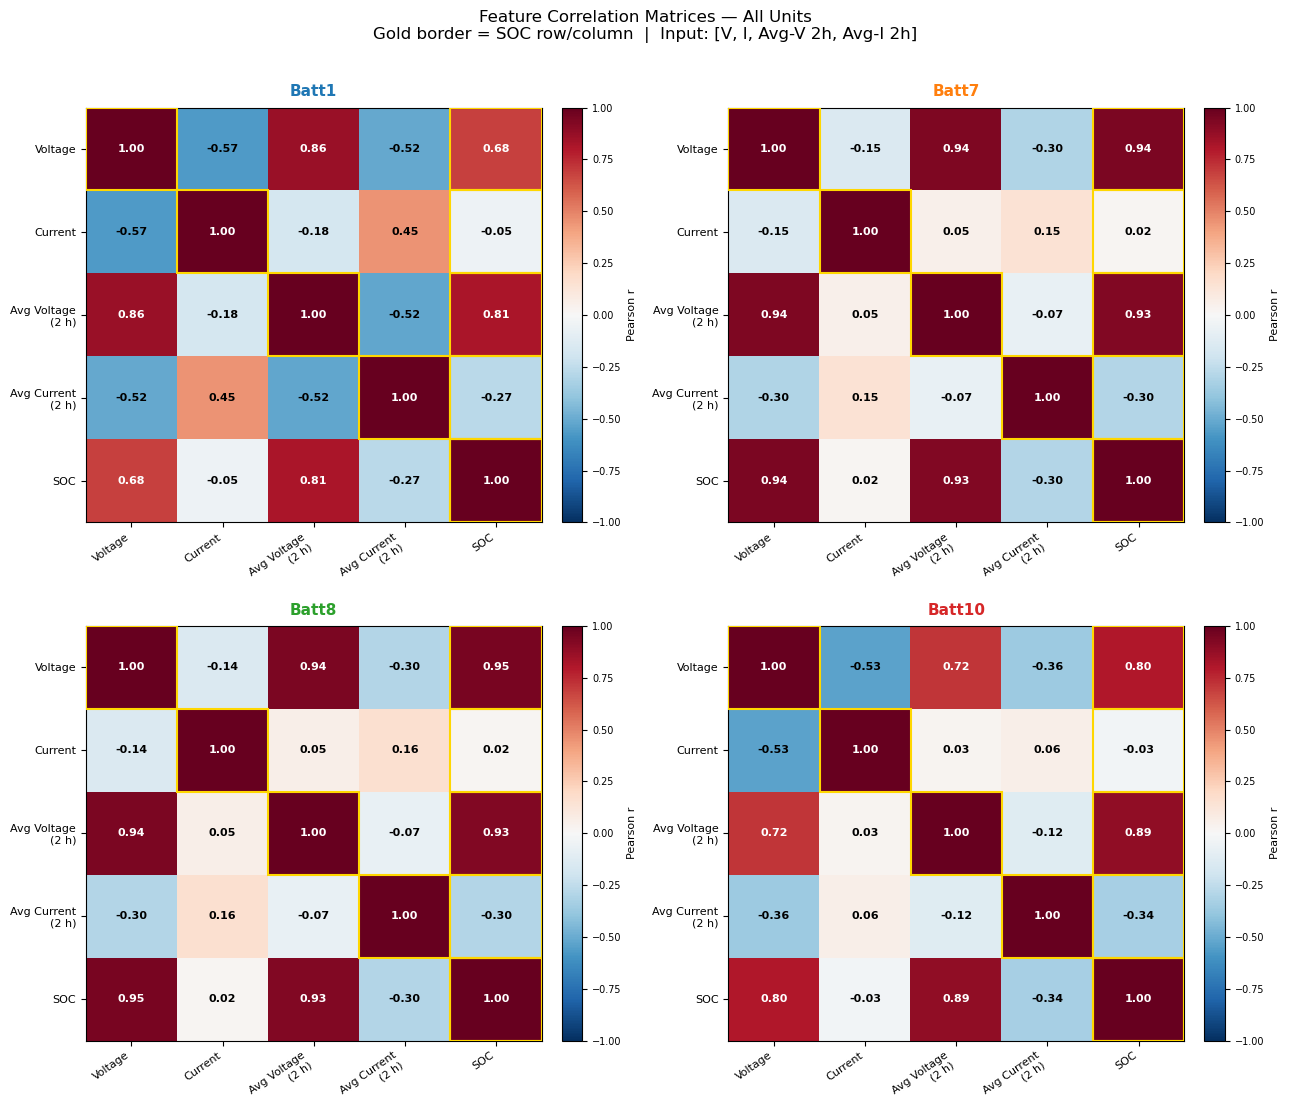

Saved → thesis_correlation_heatmaps.png


In [7]:
# ───  Correlation Heatmap:  ─────────────────────
CORR_FEATURES = ['U_DC_Batt', 'I_DC_Batt', 'V_avg_2h', 'I_avg_2h', 'SOC']
FEAT_DISPLAY  = ['Voltage', 'Current', 'Avg Voltage\n(2 h)', 'Avg Current\n(2 h)', 'SOC']

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes_flat = axes.flat

for ax, (unit_label, df) in zip(axes_flat, viz_units.items()):
    
    corr_df = df[CORR_FEATURES].rename(
        columns=dict(zip(CORR_FEATURES, FEAT_DISPLAY))
    )
    corr = corr_df.corr()

    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

    n = len(FEAT_DISPLAY)
    ax.set_xticks(range(n))
    ax.set_xticklabels(FEAT_DISPLAY, fontsize=8, rotation=35, ha='right')
    ax.set_yticks(range(n))
    ax.set_yticklabels(FEAT_DISPLAY, fontsize=8)

   
    for i in range(n):
        for j in range(n):
            val = corr.values[i, j]
            txt_col = 'white' if abs(val) > 0.65 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=txt_col, fontweight='bold')

    
    for k in range(n):
        for idx in [k, n-1]:   
            ax.add_patch(plt.Rectangle(
                (idx-0.5, k-0.5), 1, 1,
                fill=False, edgecolor='gold', lw=1.5, zorder=3
            ))

    color = UNIT_COLORS[unit_label]
    ax.set_title(UNIT_SHORT[unit_label], fontsize=11,
                 fontweight='bold', color=color, pad=8)

    # Add a colour bar for each subplot
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('Pearson r', fontsize=8)

plt.suptitle(
    'Feature Correlation Matrices — All Units\n'
    'Gold border = SOC row/column  |  Input: [V, I, Avg-V 2h, Avg-I 2h]',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'thesis_correlation_heatmaps.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved → thesis_correlation_heatmaps.png')